Comparing Two Types Of Ensemble Learning Techniques - Bagging and Boosting

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [2]:
loan_data = pd.read_csv("C:\\Loan_Dataset\\accepted_2007_to_2018Q4.csv")
columns_to_use = [
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'home_ownership',
    'annual_inc', 'purpose', 'addr_state', 'dti',
    'delinq_2yrs', 'revol_util', 'total_acc',
    'application_type', 'mort_acc', 'pub_rec_bankruptcies',
    'loan_status']
loan_data = loan_data[columns_to_use]
loan_data = loan_data.dropna() #removes 53k of 226k rows ~2.3% of data


C:\Users\joshu\AppData\Local\Temp\ipykernel_27276\165235067.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  loan_data = pd.read_csv("C:\\Loan_Dataset\\accepted_2007_to_2018Q4.csv")


In [3]:
y = loan_data.loan_status
X = loan_data.drop('loan_status', axis=1)

Encoding X and y For Model

In [4]:
X = pd.get_dummies(X)
risky_statuses = [
    'Charged Off',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'Default',
    'In Grace Period'
]
y = y.isin(risky_statuses)
y = y.astype(int)

Bagging Technique - RandomForestClassifier

In [5]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state = 1)
bagging_model = RandomForestClassifier(n_estimators=100, max_depth=3, max_samples=0.8, max_features=0.8, n_jobs=-1, random_state=1)
bagging_model.fit(train_X, train_y)
bagging_prediction = bagging_model.predict(val_X)
accuracy = accuracy_score(val_y, bagging_prediction)
print("Bagging Model Accuracy:", accuracy)

Bagging Model Accuracy: 0.8651270006958942


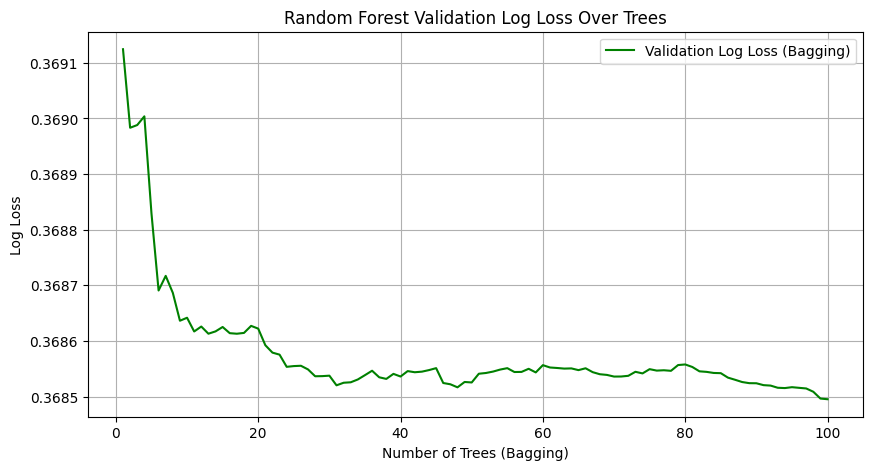

In [6]:
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import numpy as np
import warnings

logloss_vals = []
proba_accum = np.zeros((len(val_X), 2))  # for binary classification

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    for i, tree in enumerate(bagging_model.estimators_):
        y_proba = tree.predict_proba(val_X)
        proba_accum += y_proba
        avg_proba = proba_accum / (i + 1)
        loss = log_loss(val_y, avg_proba)
        logloss_vals.append(loss)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(logloss_vals) + 1), logloss_vals, label='Validation Log Loss (Bagging)', color='green')
plt.xlabel('Number of Trees (Bagging)')
plt.ylabel('Log Loss')
plt.title('Random Forest Validation Log Loss Over Trees')
plt.grid(True)
plt.legend()
plt.show()


Boosting Technique - XGBClassifier

In [7]:
boosting_model = XGBClassifier(learning_rate=0.1, n_estimators=100, max_depth=3, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=0)
#boosting_model = XGBClassifier(eval_metric='logloss', random_state=1)
boosting_model.fit( train_X, train_y, eval_set=[(val_X, val_y)], verbose=False)
boosting_prediction = boosting_model.predict(val_X)
accuracy = accuracy_score(val_y, boosting_prediction)
print("Boosting Model Accuracy:", accuracy)

Boosting Model Accuracy: 0.8651324373695198


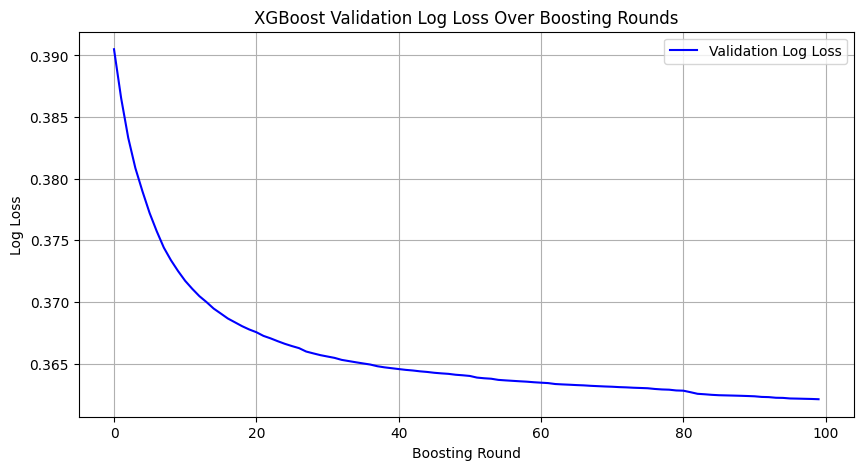

In [8]:
results = boosting_model.evals_result()
logloss_vals = results['validation_0']['logloss']
epochs = range(len(logloss_vals))

plt.figure(figsize=(10, 5))
plt.plot(epochs, logloss_vals, label='Validation Log Loss', color='blue')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('XGBoost Validation Log Loss Over Boosting Rounds')
plt.legend()
plt.grid(True)
plt.show()

Comparing Log Loss Progresson Graphs of both techniques

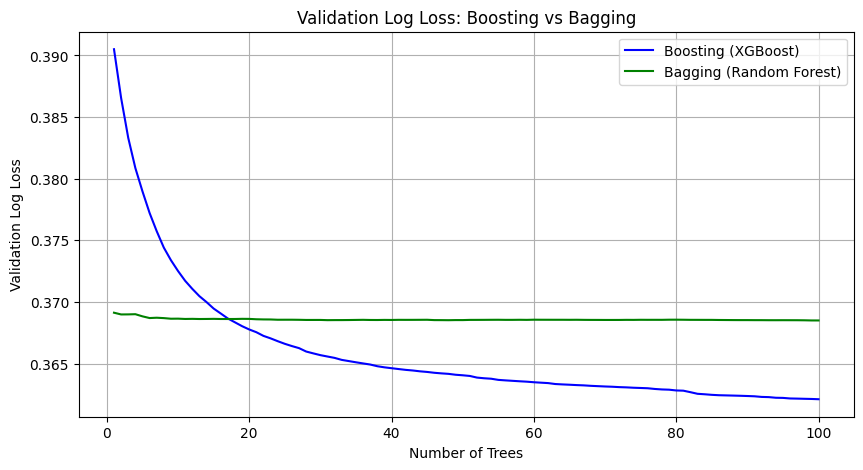

In [9]:
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import numpy as np
import warnings

# --- Bagging log loss ---
logloss_bagging = []
proba_accum = np.zeros((len(val_X), 2))  # for binary classification

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    
    for i, tree in enumerate(bagging_model.estimators_):
        y_proba = tree.predict_proba(val_X)
        proba_accum += y_proba
        avg_proba = proba_accum / (i + 1)
        loss = log_loss(val_y, avg_proba)
        logloss_bagging.append(loss)

# --- Boosting log loss ---
results = boosting_model.evals_result()
logloss_boosting = results['validation_0']['logloss']

# --- Plot both curves ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(logloss_boosting) + 1), logloss_boosting, label='Boosting (XGBoost)', color='blue')
plt.plot(range(1, len(logloss_bagging) + 1), logloss_bagging, label='Bagging (Random Forest)', color='green')
plt.xlabel('Number of Trees')
plt.ylabel('Validation Log Loss')
plt.title('Validation Log Loss: Boosting vs Bagging')
plt.grid(True)
plt.legend()
plt.show()


Automated Fine Tuning of Boosting Model using GridSearchCV

In [10]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 4, 5],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0],
#     'n_estimators': [100, 300]
# }

# grid = GridSearchCV(
#     estimator=XGBClassifier(random_state=1, use_label_encoder=False),
#     param_grid=param_grid,
#     scoring='neg_log_loss',  # or 'roc_auc' or 'accuracy'
#     cv=3,  # 3-fold cross-validation
#     verbose=1,
#     n_jobs=-1  # Use all cores
# )

# grid.fit(X, y)
# print("Best Score:", -grid.best_score_)  # Since we used neg_log_loss
# print("Best Params:", grid.best_params_)